# Brain Tumor MRI Classification

## Data Pipeline Notebook

This notebook creates an efficient TensorFlow data pipeline.

Goals:

- Load images directly from folders
- Create train and validation datasets
- Apply preprocessing
- Apply augmentation
- Optimize performance

This approach avoids loading the entire dataset into RAM.

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path

# Dataset Path

In [2]:
BASE_DIR = Path("../datasets/classification")

TRAIN_DIR = BASE_DIR / "Training"

print(TRAIN_DIR)

..\datasets\classification\Training


# Hyperparameters

In [3]:
IMG_SIZE = (128, 128)

BATCH_SIZE = 32

SEED = 42

# Training Dataset

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    
    TRAIN_DIR,
    
    validation_split=0.2,
    
    subset="training",
    
    seed=SEED,
    
    image_size=IMG_SIZE,
    
    batch_size=BATCH_SIZE
)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.


# Validation Dataset

In [5]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    
    TRAIN_DIR,
    
    validation_split=0.2,
    
    subset="validation",
    
    seed=SEED,
    
    image_size=IMG_SIZE,
    
    batch_size=BATCH_SIZE
)

Found 5600 files belonging to 4 classes.
Using 1120 files for validation.


# Class Names

In [6]:
class_names = train_ds.class_names

print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


# Visualize Batch

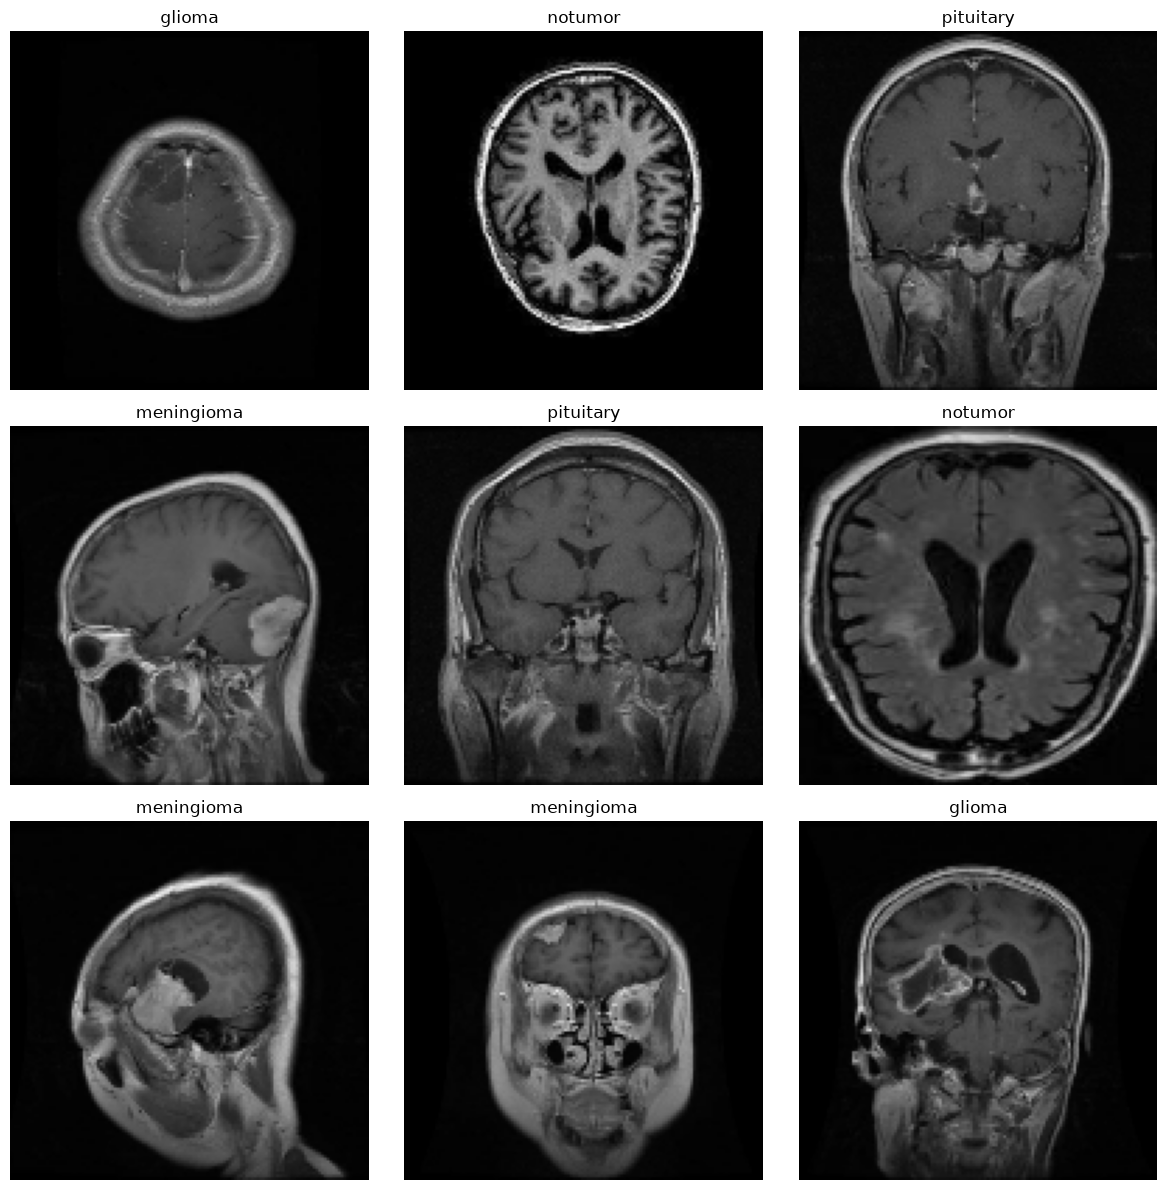

In [7]:
plt.figure(figsize=(12,12))

for images, labels in train_ds.take(1):
    
    for i in range(9):
        
        plt.subplot(3,3,i+1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            class_names[labels[i]]
        )

        plt.axis("off")

plt.tight_layout()

plt.show()

# Dataset Shapes

In [8]:
for images, labels in train_ds.take(1):
    
    print("Images Shape:", images.shape)
    
    print("Labels Shape:", labels.shape)

Images Shape: (32, 128, 128, 3)
Labels Shape: (32,)


# Data Augmentation

In [10]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.05),

    tf.keras.layers.RandomZoom(0.1)

])

# Test Augmentation

In [11]:
for images, labels in train_ds.take(1):

    sample_image = images[0]

    break

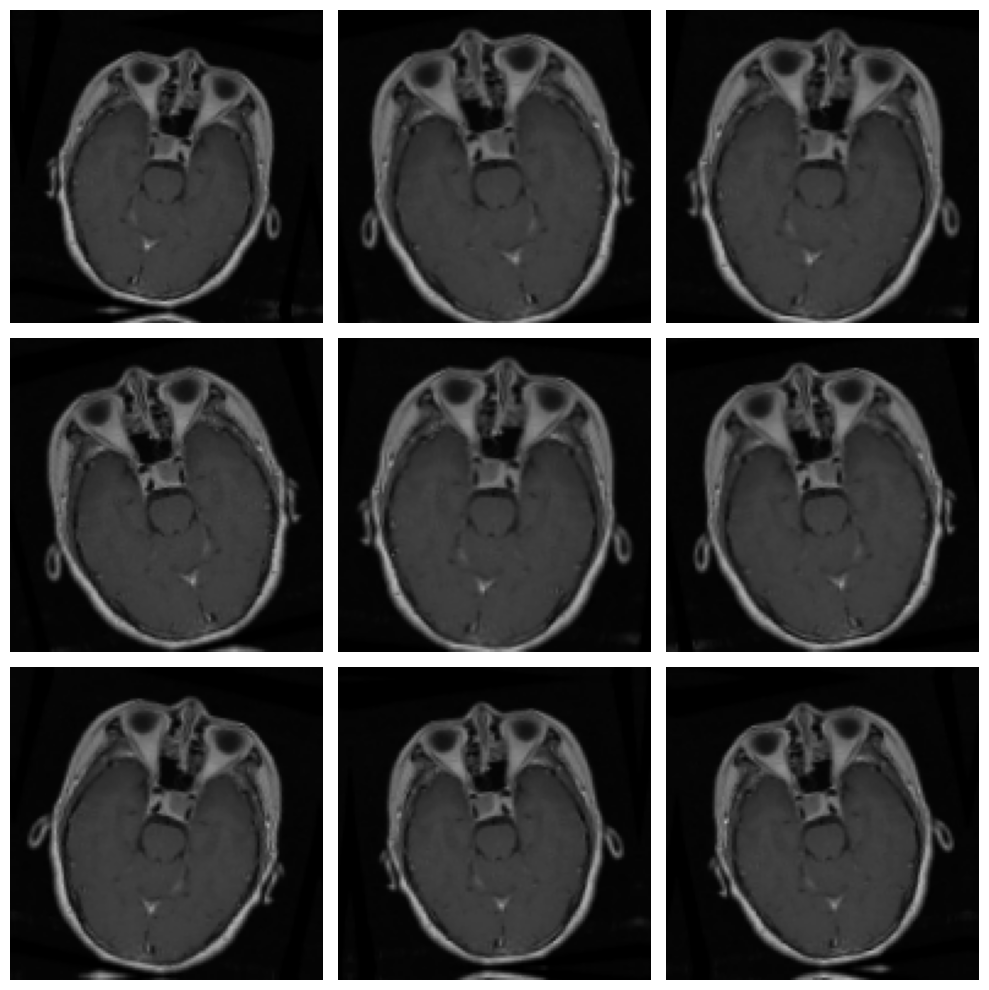

In [12]:
plt.figure(figsize=(10,10))

for i in range(9):

    augmented = data_augmentation(
        tf.expand_dims(sample_image,0)
    )

    ax = plt.subplot(3,3,i+1)

    plt.imshow(
        augmented[0].numpy().astype("uint8")
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

# Normalize Pixel Values

In [13]:
normalization_layer = tf.keras.layers.Rescaling(
    1./255
)

# Apply Normalization

In [14]:
normalized_ds = train_ds.map(
    lambda x,y:
    (
        normalization_layer(x),
        y
    )
)

In [15]:
for images, labels in normalized_ds.take(1):

    print(images.numpy().min())

    print(images.numpy().max())

0.0
1.0


# Optimize Pipeline

In [16]:
AUTOTUNE = tf.data.AUTOTUNE

In [17]:
train_ds = train_ds.prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.prefetch(
    buffer_size=AUTOTUNE
)

# Dataset Summary

In [18]:
print("Classes:", class_names)

print("Image Size:", IMG_SIZE)

print("Batch Size:", BATCH_SIZE)

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Image Size: (128, 128)
Batch Size: 32
